# Сравнение различных трансформерных моделей для последовательностей

## Часть 1: Настройка окружения

Инициализация зависимостей, логирования и параметров визуализации.

In [1]:
import logging
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

reset_seeds(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
logger.info(f'Окружение инициализировано. Устройство: {device}')

2026-04-08 15:46:50,799 - INFO - Окружение инициализировано. Устройство: mps


## Часть 2: Загрузка и подготовка данных

Загрузка транзакций и организация их в последовательности по клиентам.

In [2]:
df_train = pd.read_csv('train.csv')
df_val = pd.read_csv('val.csv')
df_test = pd.read_csv('test.csv')

logger.info(f"Тренировочный набор: {df_train.shape[0]:,} транзакций x {df_train.shape[1]} признаков")
logger.info(f"Валидационный набор: {df_val.shape[0]:,} транзакций x {df_val.shape[1]} признаков")
logger.info(f"Тестовый набор: {df_test.shape[0]:,} транзакций x {df_test.shape[1]} признаков")
logger.info(f"Доля мошенничества (тренировка): {df_train['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (валидация): {df_val['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (тест): {df_test['FraudResult'].mean():.2%}")

print('\nСводка данных:')
print(f"  Уникальных клиентов (тренировка): {df_train['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (валидация): {df_val['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (тест): {df_test['CustomerId'].nunique():,}")
print(f"  Средний размер последовательности: {len(df_train) / df_train['CustomerId'].nunique():.1f} транзакций")

2026-04-08 15:46:50,917 - INFO - Тренировочный набор: 54,459 транзакций x 10 признаков
2026-04-08 15:46:50,918 - INFO - Валидационный набор: 21,537 транзакций x 10 признаков
2026-04-08 15:46:50,918 - INFO - Тестовый набор: 19,666 транзакций x 10 признаков
2026-04-08 15:46:50,920 - INFO - Доля мошенничества (тренировка): 0.17%
2026-04-08 15:46:50,921 - INFO - Доля мошенничества (валидация): 0.21%
2026-04-08 15:46:50,922 - INFO - Доля мошенничества (тест): 0.29%



Сводка данных:
  Уникальных клиентов (тренировка): 2,245
  Уникальных клиентов (валидация): 748
  Уникальных клиентов (тест): 749
  Средний размер последовательности: 24.3 транзакций


## Часть 3: Инженерия признаков и подготовка последовательностей

Извлечение признаков и организация данных в последовательности для обработки трансформеров.

In [3]:
def prepare_transaction_features(df):
    df = df.copy()
    id_columns = ['ProviderId', 'ProductId', 'ChannelId']

    for col in id_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.extract(r'(\d+)$', expand=False).astype('Int64')

    if 'TransactionStartTime' in df.columns:
        df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'], utc=True)
        df['tx_hour'] = df['TransactionStartTime'].dt.hour
        df['tx_dayofweek'] = df['TransactionStartTime'].dt.dayofweek
        df['tx_month'] = df['TransactionStartTime'].dt.month
        df['tx_is_weekend'] = (df['TransactionStartTime'].dt.dayofweek >= 5).astype(int)
        df = df.drop(columns=['TransactionStartTime'])

    return df

logger.info('Подготовка признаков для транзакций...')
train_features = prepare_transaction_features(df_train)
val_features = prepare_transaction_features(df_val)
test_features = prepare_transaction_features(df_test)

if 'ProductCategory' in train_features.columns:
    train_features['ProductCategory'] = train_features['ProductCategory'].fillna('__MISSING__').astype(str)
    val_features['ProductCategory'] = val_features['ProductCategory'].fillna('__MISSING__').astype(str)
    test_features['ProductCategory'] = test_features['ProductCategory'].fillna('__MISSING__').astype(str)

    product_category_mapping = {
        category: idx
        for idx, category in enumerate(train_features['ProductCategory'].unique())
    }

    train_features['ProductCategory'] = train_features['ProductCategory'].map(product_category_mapping).fillna(-1).astype(int)
    val_features['ProductCategory'] = val_features['ProductCategory'].map(product_category_mapping).fillna(-1).astype(int)
    test_features['ProductCategory'] = test_features['ProductCategory'].map(product_category_mapping).fillna(-1).astype(int)

common_cols = sorted(list(set(train_features.columns) & set(val_features.columns) & set(test_features.columns)))
train_features = train_features[common_cols]
val_features = val_features[common_cols]
test_features = test_features[common_cols]

logger.info(f'Признаки подготовлены - {train_features.shape[1]} признаков')
logger.info(f'Выровненные колонки: {common_cols}')

2026-04-08 15:46:50,972 - INFO - Подготовка признаков для транзакций...
2026-04-08 15:46:51,164 - INFO - Признаки подготовлены - 13 признаков
2026-04-08 15:46:51,165 - INFO - Выровненные колонки: ['Amount', 'ChannelId', 'CustomerId', 'FraudResult', 'PricingStrategy', 'ProductCategory', 'ProductId', 'ProviderId', 'TransactionId', 'tx_dayofweek', 'tx_hour', 'tx_is_weekend', 'tx_month']


### Создание последовательностей для каждого клиента

In [4]:
def create_client_sequences(df, max_seq_len=100):
    TARGET_COL = 'FraudResult'
    CLIENT_ID_COL = 'CustomerId'
    exclude_cols = {TARGET_COL, 'TransactionId', 'BatchId', 'SubscriptionId', 'CustomerId', 'quantile'}
    feature_cols = [c for c in df.columns if c not in exclude_cols]

    sequences, labels, client_ids = [], [], []

    for account_id, group in df.groupby(CLIENT_ID_COL, sort=False):
        seq = group[feature_cols].values.astype(np.float32)

        if len(seq) > max_seq_len:
            seq = seq[-max_seq_len:]

        if len(seq) < max_seq_len:
            padding = np.zeros((max_seq_len - len(seq), seq.shape[1]), dtype=np.float32)
            seq = np.vstack([padding, seq])

        label = int(group[TARGET_COL].max())
        sequences.append(seq)
        labels.append(label)
        client_ids.append(account_id)

    return np.array(sequences), np.array(labels), np.array(client_ids), feature_cols

logger.info('Создание последовательностей клиентов...')
train_sequences, train_labels, train_clients, feature_cols = create_client_sequences(train_features)
val_sequences, val_labels, val_clients, _ = create_client_sequences(val_features)
test_sequences, test_labels, test_clients, _ = create_client_sequences(test_features)

logger.info(f'Тренировочные последовательности: {train_sequences.shape}')
logger.info(f'Валидационные последовательности: {val_sequences.shape}')
logger.info(f'Тестовые последовательности: {test_sequences.shape}')
logger.info(f'Распределение меток (тренировка): {np.bincount(train_labels)}')
logger.info(f'Распределение меток (валидация): {np.bincount(val_labels)}')
logger.info(f'Распределение меток (тест): {np.bincount(test_labels)}')
logger.info(f'Всего признаков в последовательности: {len(feature_cols)}')

print(f'\nРазмер последовательностей:')
print(f'  Максимальная длина: 100 транзакций')
print(f'  Размер признаков: {train_sequences.shape[2]}')
print(f'  Клиентов (тренировка): {len(train_sequences)}')
print(f'  Клиентов (валидация): {len(val_sequences)}')
print(f'  Клиентов (тест): {len(test_sequences)}')

2026-04-08 15:46:51,170 - INFO - Создание последовательностей клиентов...
2026-04-08 15:46:51,939 - INFO - Тренировочные последовательности: (2245, 100, 10)
2026-04-08 15:46:51,939 - INFO - Валидационные последовательности: (748, 100, 10)
2026-04-08 15:46:51,939 - INFO - Тестовые последовательности: (749, 100, 10)
2026-04-08 15:46:51,940 - INFO - Распределение меток (тренировка): [2213   32]
2026-04-08 15:46:51,940 - INFO - Распределение меток (валидация): [735  13]
2026-04-08 15:46:51,940 - INFO - Распределение меток (тест): [740   9]
2026-04-08 15:46:51,940 - INFO - Всего признаков в последовательности: 10



Размер последовательностей:
  Максимальная длина: 100 транзакций
  Размер признаков: 10
  Клиентов (тренировка): 2245
  Клиентов (валидация): 748
  Клиентов (тест): 749


### Нормализация признаков

In [5]:
n_clients, seq_len, n_features = train_sequences.shape
training_reshaped = train_sequences.reshape(-1, n_features)

scaler = StandardScaler()
training_scaled_reshaped = scaler.fit_transform(training_reshaped)
training_sequences_scaled = training_scaled_reshaped.reshape(n_clients, seq_len, n_features)

val_reshaped = val_sequences.reshape(-1, n_features)
val_scaled_reshaped = scaler.transform(val_reshaped)
val_sequences_scaled = val_scaled_reshaped.reshape(val_sequences.shape[0], seq_len, n_features)

test_reshaped = test_sequences.reshape(-1, n_features)
test_scaled_reshaped = scaler.transform(test_reshaped)
test_sequences_scaled = test_scaled_reshaped.reshape(test_sequences.shape[0], seq_len, n_features)

logger.info('Признаки нормализованы')
print(f"Нормализация - Статистика тренировки:")
print(f"  Mean: {training_sequences_scaled.reshape(-1, n_features).mean(axis=0)[:5]}...")
print(f"  Std:  {training_sequences_scaled.reshape(-1, n_features).std(axis=0)[:5]}...")

2026-04-08 15:46:51,971 - INFO - Признаки нормализованы


Нормализация - Статистика тренировки:
  Mean: [ 1.8011113e-05 -1.5995996e-04  2.7012502e-05  1.8363736e-04
  2.7989814e-04]...
  Std:  [0.9996074  0.99843687 1.0012281  0.99954414 1.0011429 ]...


### Преобразование в PyTorch tensors

In [6]:
X_train_tensor = torch.FloatTensor(training_sequences_scaled)
y_train_tensor = torch.LongTensor(train_labels)

X_val_tensor = torch.FloatTensor(val_sequences_scaled)
y_val_tensor = torch.LongTensor(val_labels)

X_test_tensor = torch.FloatTensor(test_sequences_scaled)
y_test_tensor = torch.LongTensor(test_labels)

logger.info(f'Тренировочные тензоры: {X_train_tensor.shape}')
logger.info(f'Валидационные тензоры: {X_val_tensor.shape}')
logger.info(f'Тестовые тензоры: {X_test_tensor.shape}')

2026-04-08 15:46:51,990 - INFO - Тренировочные тензоры: torch.Size([2245, 100, 10])
2026-04-08 15:46:51,990 - INFO - Валидационные тензоры: torch.Size([748, 100, 10])
2026-04-08 15:46:51,990 - INFO - Тестовые тензоры: torch.Size([749, 100, 10])


## Часть 4: Архитектуры трансформерных моделей для последовательностей

В этом разделе рассматриваются несколько близких по смыслу attention-моделей. Общая идея сохраняется прежней: сначала сравниваются несколько представителей одного класса архитектур, после чего лучший из них можно тюнить отдельно.

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerMeanPoolingClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, num_classes=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        pooled = torch.mean(x, dim=1)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

class TransformerCLSTokenClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, num_classes=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_encoder = PositionalEncoding(d_model, max_len=5001)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.input_proj(x)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        cls_repr = self.dropout(x[:, 0, :])
        return self.classifier(cls_repr)

class TransformerAttentionPoolingClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, num_classes=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.attention = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.Tanh(), nn.Linear(d_model // 2, 1)
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        attn_scores = self.attention(x)
        attn_weights = torch.softmax(attn_scores, dim=1)
        pooled = torch.sum(x * attn_weights, dim=1)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

class TransformerMeanMaxPoolingClassifier(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, num_classes=2, dropout=0.2):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        mean_pooled = torch.mean(x, dim=1)
        max_pooled, _ = torch.max(x, dim=1)
        pooled = torch.cat([mean_pooled, max_pooled], dim=1)
        pooled = self.dropout(pooled)
        return self.classifier(pooled)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)
        targets = targets.view(-1, 1)
        log_pt = log_probs.gather(1, targets).squeeze(1)
        pt = probs.gather(1, targets).squeeze(1)

        if self.alpha is not None:
            at = self.alpha.gather(0, targets.squeeze(1))
            loss = -at * ((1 - pt) ** self.gamma) * log_pt
        else:
            loss = -((1 - pt) ** self.gamma) * log_pt

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

model_configs = {
    'TransformerMean': {'model_type': 'transformer_mean', 'd_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.2},
    'TransformerCLS': {'model_type': 'transformer_cls', 'd_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.2},
    'TransformerAttention': {'model_type': 'transformer_attention', 'd_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.2},
    'TransformerMeanMax': {'model_type': 'transformer_meanmax', 'd_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.2},
}

def build_model(config, input_dim, num_classes=2):
    if config['model_type'] == 'transformer_mean':
        model = TransformerMeanPoolingClassifier(input_dim=input_dim, d_model=config['d_model'], nhead=config['nhead'], num_layers=config['num_layers'], dim_feedforward=config['dim_feedforward'], num_classes=num_classes, dropout=config['dropout'])
    elif config['model_type'] == 'transformer_cls':
        model = TransformerCLSTokenClassifier(input_dim=input_dim, d_model=config['d_model'], nhead=config['nhead'], num_layers=config['num_layers'], dim_feedforward=config['dim_feedforward'], num_classes=num_classes, dropout=config['dropout'])
    elif config['model_type'] == 'transformer_attention':
        model = TransformerAttentionPoolingClassifier(input_dim=input_dim, d_model=config['d_model'], nhead=config['nhead'], num_layers=config['num_layers'], dim_feedforward=config['dim_feedforward'], num_classes=num_classes, dropout=config['dropout'])
    elif config['model_type'] == 'transformer_meanmax':
        model = TransformerMeanMaxPoolingClassifier(input_dim=input_dim, d_model=config['d_model'], nhead=config['nhead'], num_layers=config['num_layers'], dim_feedforward=config['dim_feedforward'], num_classes=num_classes, dropout=config['dropout'])
    else:
        raise ValueError(f"Неизвестный тип модели: {config['model_type']}")
    return model.to(device)

for model_name, config in model_configs.items():
    model = build_model(config, input_dim=n_features)
    n_params = sum(p.numel() for p in model.parameters())
    logger.info(f'{model_name}: {n_params:,} параметров')

2026-04-08 15:46:52,069 - INFO - TransformerMean: 69,794 параметров
2026-04-08 15:46:52,091 - INFO - TransformerCLS: 69,858 параметров
2026-04-08 15:46:52,112 - INFO - TransformerAttention: 71,907 параметров
2026-04-08 15:46:52,130 - INFO - TransformerMeanMax: 78,050 параметров


## Часть 5: Обучение и сравнение моделей

Процедура обучения сохраняется близкой к ноутбуку с рекуррентными моделями. Для всех моделей используются одинаковые базовые настройки, чтобы сравнение было максимально честным.

In [8]:
def train_epoch(model, train_loader, optimizer, criterion, device, clip_grad=1.0):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        if clip_grad > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(train_loader.dataset)

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            labels = y_batch.cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels)
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    pr_auc = average_precision_score(all_labels, all_probs)
    return total_loss / len(val_loader.dataset), pr_auc

def predict_on_loader(model, data_loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())
    return np.array(all_labels), np.array(all_probs)

def find_best_threshold(y_true, y_score, beta=0.5):
    thresholds = np.arange(0.0, 1.01, 0.01)
    fbeta_scores = []
    for thresh in thresholds:
        y_pred_thresh = (y_score >= thresh).astype(int)
        score = fbeta_score(y_true, y_pred_thresh, beta=beta, zero_division=0)
        fbeta_scores.append(score)
    best_idx = int(np.argmax(fbeta_scores))
    return thresholds[best_idx], fbeta_scores[best_idx], thresholds, fbeta_scores

def calculate_metrics(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    metrics = {
        'ROC-AUC': roc_auc_score(y_true, y_score),
        'PR-AUC': average_precision_score(y_true, y_score),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'F0.5': fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
    }
    return y_pred, metrics

## Часть 6: Сравнительная оценка моделей

На этом этапе модели обучаются по единой схеме, после чего на validation подбирается оптимальный порог по F0.5. Итоговая оценка проводится на тестовой выборке.

In [9]:
results = []
trained_models = {}
training_histories = {}

common_batch_size = 64
common_num_epochs = 40
common_patience = 8

for model_name, config in model_configs.items():
    reset_seeds(42)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=common_batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=common_batch_size, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=common_batch_size, shuffle=False)

    logger.info(f"\n{'=' * 90}")
    logger.info(f'Запуск модели: {model_name}')
    logger.info(f'Конфиг: {config}')
    logger.info(f"{'=' * 90}")

    model = build_model(config, input_dim=n_features)
    n_params = sum(p.numel() for p in model.parameters())

    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.0], dtype=torch.float32).to(device))
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    best_pr_auc = 0.0
    patience_counter = 0
    best_state_dict = None

    train_losses, val_losses, val_pr_aucs, learning_rates = [], [], [], []

    for epoch in range(common_num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_pr_auc = validate(model, val_loader, criterion, device)
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_pr_aucs.append(val_pr_auc)
        learning_rates.append(optimizer.param_groups[0]['lr'])

        if (epoch + 1) % 5 == 0:
            logger.info(
                f"{model_name} | эпоха {epoch + 1:02d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_pr_auc={val_pr_auc:.4f}"
            )

        if val_pr_auc > best_pr_auc:
            best_pr_auc = val_pr_auc
            patience_counter = 0
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= common_patience:
                logger.info(f'{model_name}: ранняя остановка на эпохе {epoch + 1}')
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(device)

    y_val_true, y_val_score = predict_on_loader(model, val_loader, device)
    best_threshold, best_f05, thresholds, fbeta_scores = find_best_threshold(y_val_true, y_val_score, beta=0.5)

    y_test_true, y_test_score = predict_on_loader(model, test_loader, device)
    y_test_pred, test_metrics = calculate_metrics(y_test_true, y_test_score, threshold=best_threshold)

    results.append({
        'Model': model_name,
        'Params': n_params,
        'Best Val PR-AUC': best_pr_auc,
        'Best Threshold': best_threshold,
        **test_metrics
    })

    trained_models[model_name] = model
    training_histories[model_name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_pr_aucs': val_pr_aucs,
        'learning_rates': learning_rates,
        'y_val_true': y_val_true,
        'y_val_score': y_val_score,
        'y_test_true': y_test_true,
        'y_test_score': y_test_score,
        'y_test_pred': y_test_pred,
        'best_threshold': best_threshold,
        'best_f05': best_f05,
    }

    logger.info(
        f"{model_name}: test PR-AUC={test_metrics['PR-AUC']:.4f}, "
        f"ROC-AUC={test_metrics['ROC-AUC']:.4f}, "
        f"F0.5={test_metrics['F0.5']:.4f}, "
        f"Precision={test_metrics['Precision']:.4f}, "
        f"Recall={test_metrics['Recall']:.4f}"
    )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['PR-AUC', 'F0.5'], ascending=False).reset_index(drop=True)

print('\nСводная таблица результатов:')
display(results_df)

2026-04-08 15:46:52,148 - INFO - 
2026-04-08 15:46:52,148 - INFO - Запуск модели: TransformerMean
2026-04-08 15:46:52,148 - INFO - Конфиг: {'model_type': 'transformer_mean', 'd_model': 64, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 128, 'dropout': 0.2}
2026-04-08 15:46:52,148 - INFO - ==========================================================================================
2026-04-08 15:46:59,072 - INFO - TransformerMean | эпоха 05 | train_loss=0.1410 | val_loss=0.1032 | val_pr_auc=0.7861
2026-04-08 15:47:02,711 - INFO - TransformerMean | эпоха 10 | train_loss=0.0955 | val_loss=0.1116 | val_pr_auc=0.8212
2026-04-08 15:47:03,425 - INFO - TransformerMean: ранняя остановка на эпохе 11
2026-04-08 15:47:03,712 - INFO - TransformerMean: test PR-AUC=0.7748, ROC-AUC=0.8877, F0.5=0.8163, Precision=0.8000, Recall=0.8889
2026-04-08 15:47:03,715 - INFO - 
2026-04-08 15:47:03,715 - INFO - Запуск модели: TransformerCLS
2026-04-08 15:47:03,715 - INFO - Конфиг: {'model_type': 'transformer_cls', 


Сводная таблица результатов:


,Model,Params,Best Val PR-AUC,Best Threshold,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1,F0.5,Specificity,FPR,FNR,NPV,TN,FP,FN,TP
0,TransformerMeanMax,78050,0.928102,0.93,0.998048,0.867664,0.991989,0.636364,0.777778,0.700000,0.660377,0.994595,0.005405,0.222222,0.997290,736,4,2,7
1,TransformerCLS,69858,0.918791,0.97,0.986186,0.806317,0.994660,0.777778,0.777778,0.777778,0.777778,0.997297,0.002703,0.222222,0.997297,738,2,2,7
2,TransformerMean,69794,0.848502,0.98,0.887688,0.774792,0.995995,0.800000,0.888889,0.842105,0.816327,0.997297,0.002703,0.111111,0.998647,738,2,1,8
3,TransformerAttention,71907,0.932088,0.95,0.923874,0.756814,0.991989,0.666667,0.666667,0.666667,0.666667,0.995946,0.004054,0.333333,0.995946,737,3,3,6


## Часть 7: Визуализация результатов сравнения

Для удобства интерпретации полезно отдельно визуализировать итоговые метрики всех моделей.

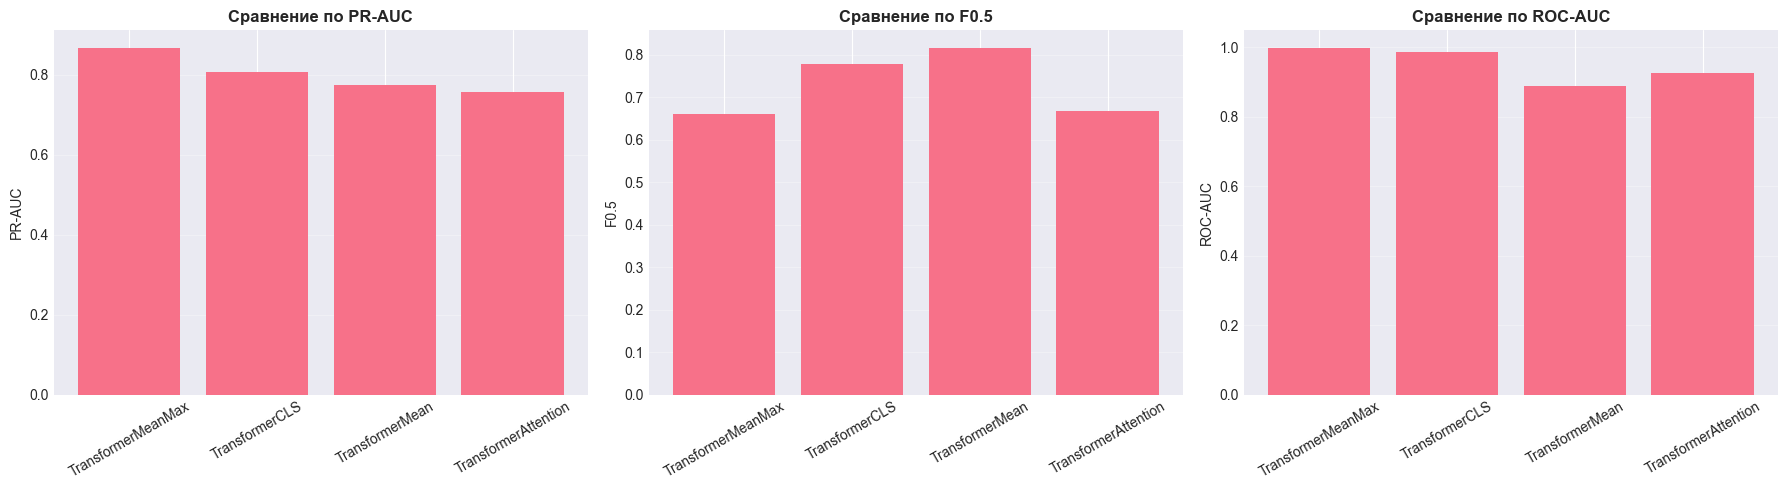

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(results_df['Model'], results_df['PR-AUC'])
axes[0].set_title('Сравнение по PR-AUC', fontsize=12, fontweight='bold')
axes[0].set_ylabel('PR-AUC')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(results_df['Model'], results_df['F0.5'])
axes[1].set_title('Сравнение по F0.5', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F0.5')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(results_df['Model'], results_df['ROC-AUC'])
axes[2].set_title('Сравнение по ROC-AUC', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ROC-AUC')
axes[2].tick_params(axis='x', rotation=30)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()